# Viscosity Pipeline Usage Example

This notebook shows how to run the reusable viscosity pipeline on:
'dynamic_analysis_full_run_custom_20260513_093259.csv'
Workflow covered:
1. Load dataset
2. Normalize x-axis by cell
3. Trim before-hit and after-contact zones
4. Fit Polynomial(2nd) and Hyperbola
5. Map known real viscosities (user input)
6. Extrapolate unknown viscosities
7. Plot fits and accuracy

In [1]:
import sys
from pathlib import Path

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "viscometry").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (expected src/viscometry)")

PROJECT_ROOT = _find_repo_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

AUTO_RUNS = PROJECT_ROOT / "results" / "auto_runs"
AUTO_RUNS_LEGACY = PROJECT_ROOT / "results" / "Auto-runs"
ARCHIVE = PROJECT_ROOT / "results" / "runs" / "archive"

from pathlib import Path
import sys

import pandas as pd

# Locate helper module robustly across common notebook working directories.
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / 'results' / 'Auto-runs',
    Path.cwd().parent,
]
if helper_dir is None:
from viscometry.analysis.viscosity_pipeline import run_viscosity_pipeline

In [2]:
# Dataset to analyze
csv_filename = 'full_run_260428.csv'
#sv_filename = 'dynamic_analysis_full_run_custom_20260513_093259.csv'

csv_candidates = [
    Path.cwd() / csv_filename,
    Path.cwd() / 'results' / 'Auto-runs' / csv_filename,
    helper_dir / csv_filename,
    helper_dir.parent / 'results' / 'Auto-runs' / csv_filename,
]
csv_path_obj = next((path for path in csv_candidates if path.exists()), None)
if csv_path_obj is None:
    raise FileNotFoundError(f'CSV file not found: {csv_filename}')
csv_path = str(csv_path_obj)

# USER INPUT: known calibration viscosities in cP.
# Keep only cells you trust for calibration. Unknown cells can be omitted.

real_viscosity_map = {
     1: 1000,
     2: 1154,
     3: 3347,
     4: 6611,
     5: 5865,
     6: 8930,
     7: 11860,
     8: 14590,
     9: 19000,
     10: 22730,
     11: 31870,
     12: 40850,
     13: 48520,
     14: 37020,
     15: 69080,
     16: 70730,
     17: 93270,
     18: 124800,
  }

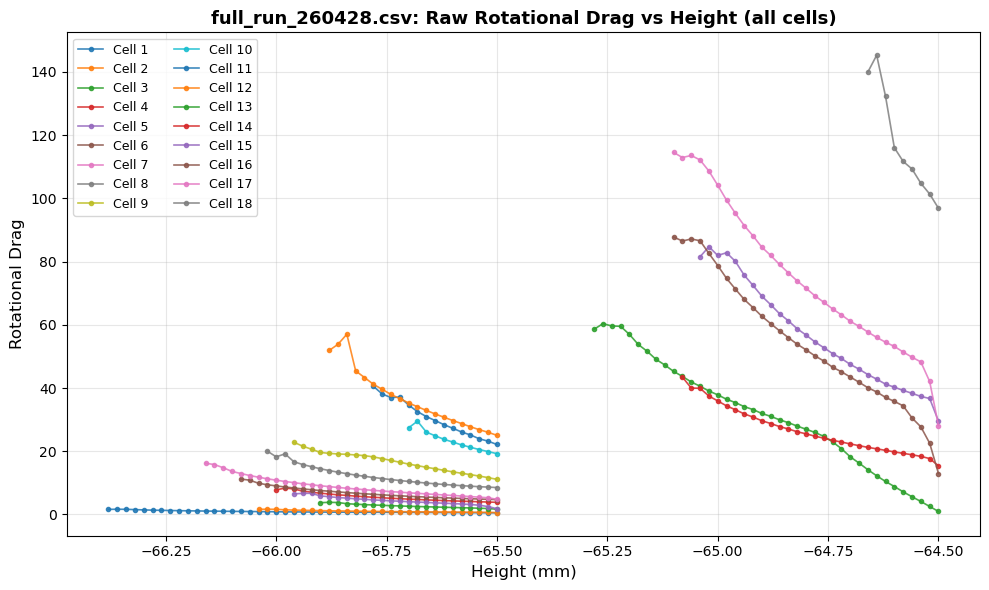

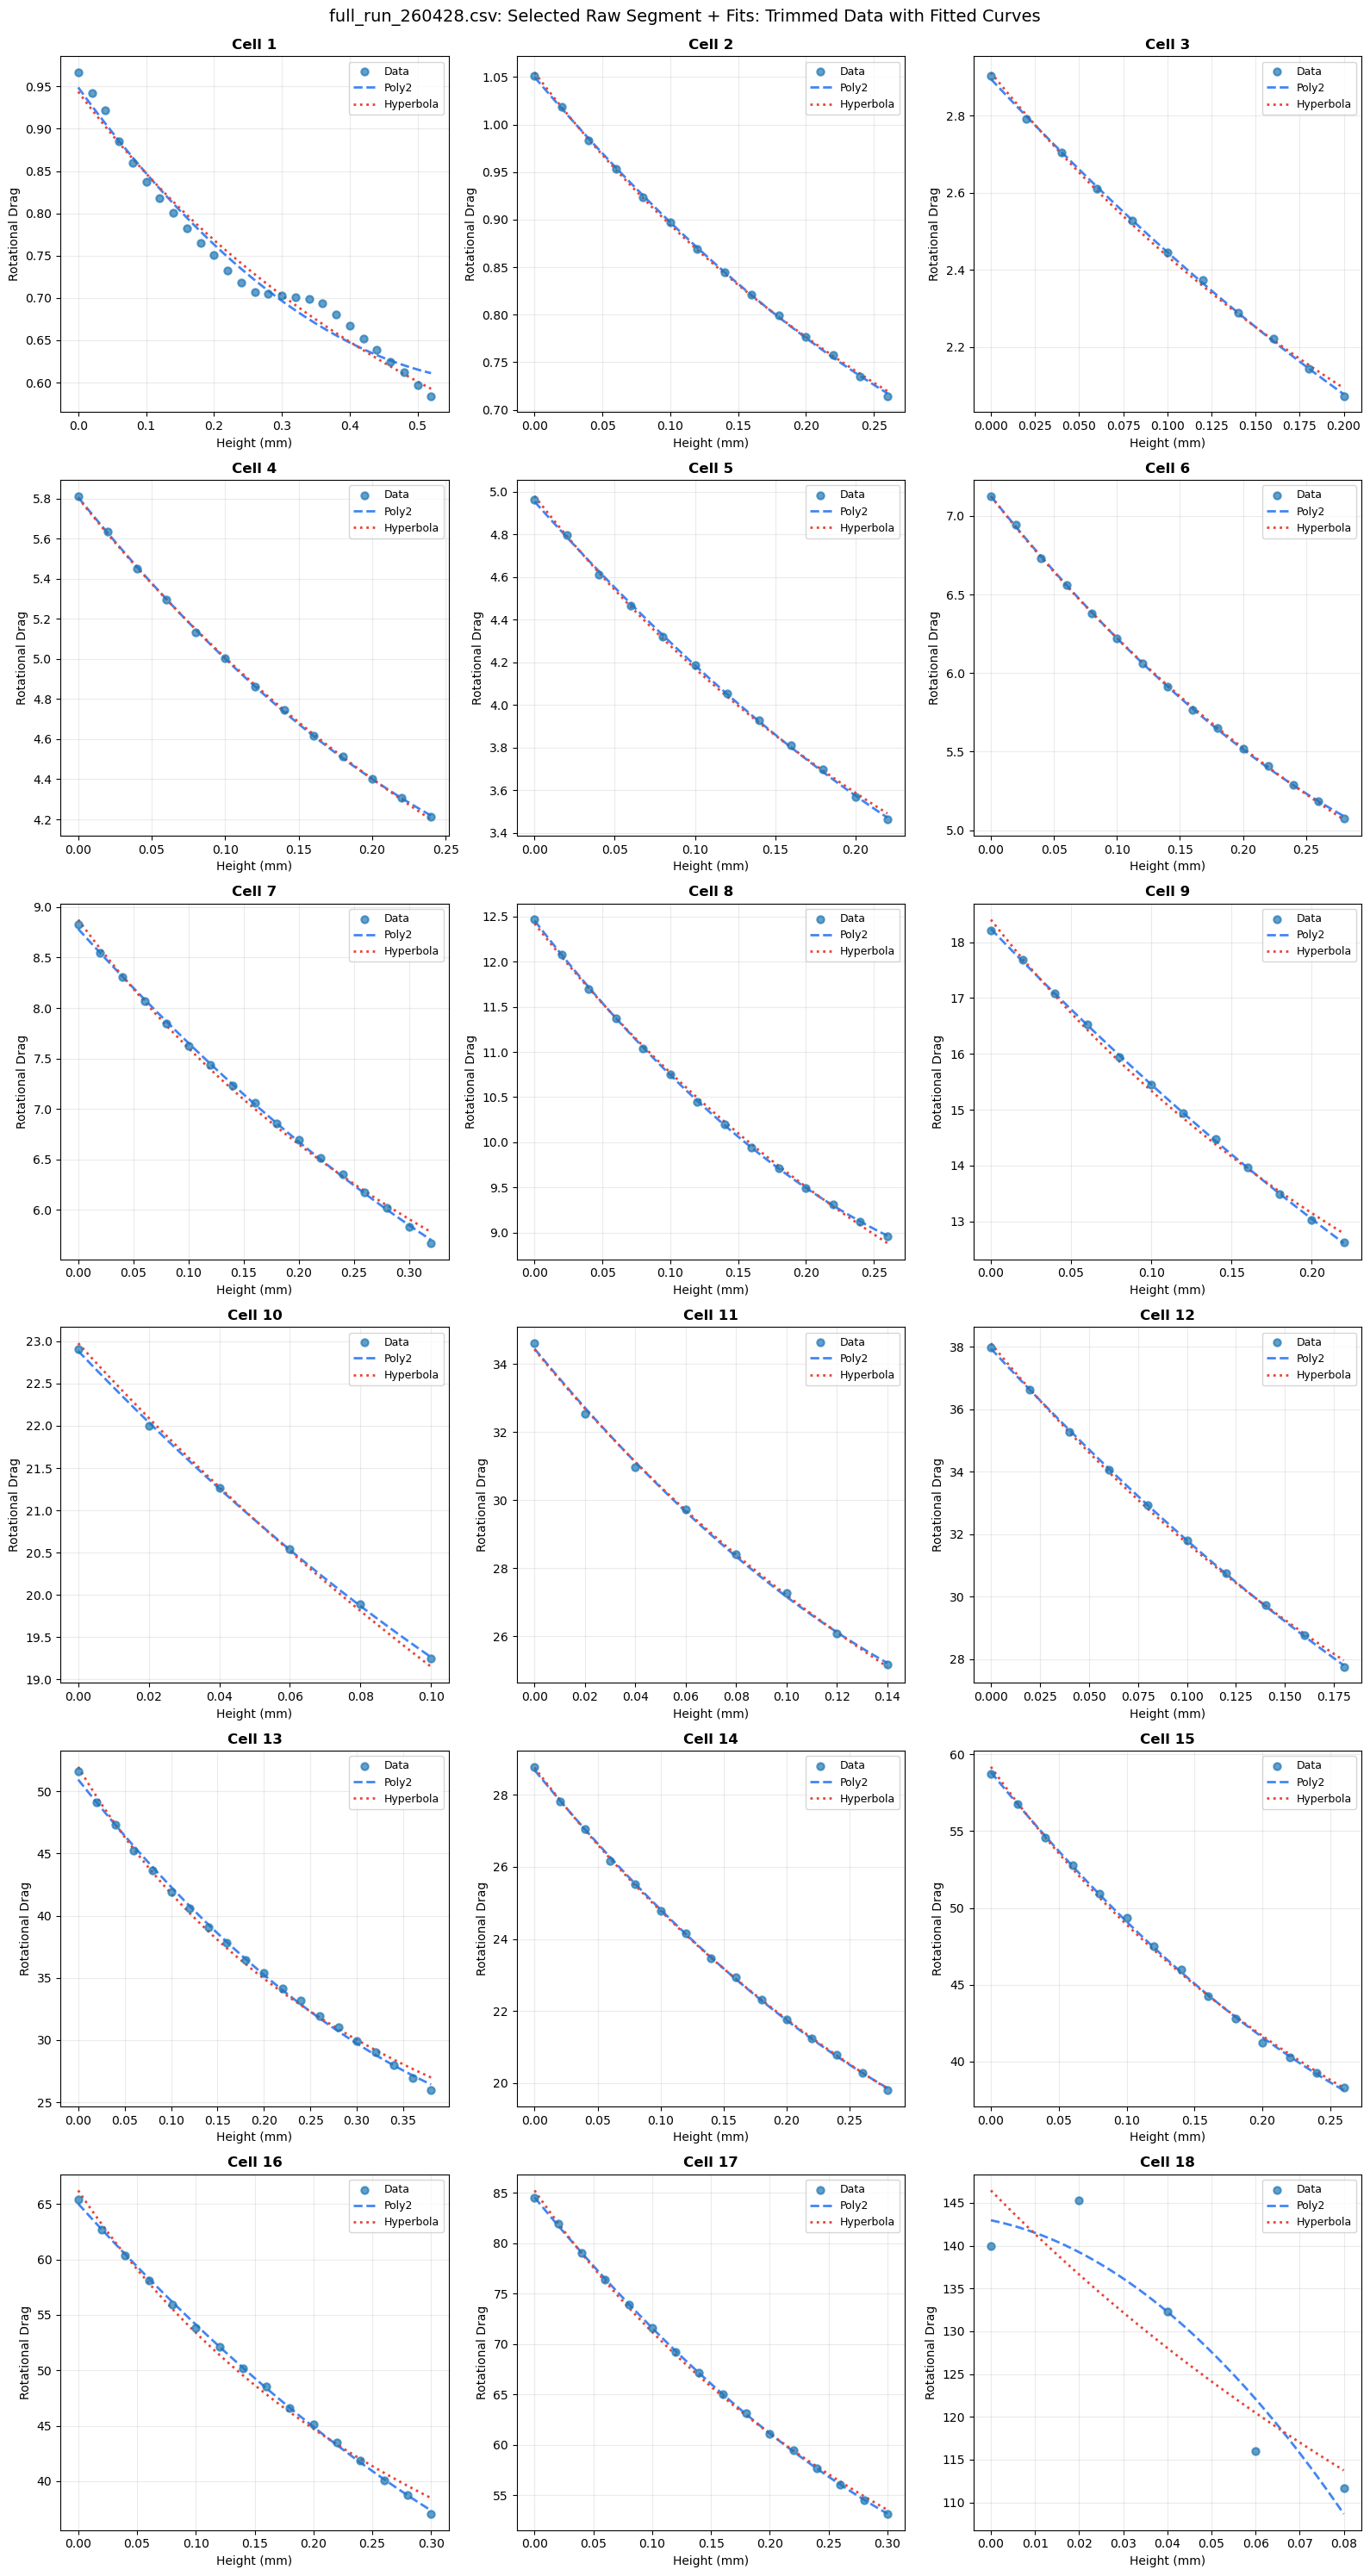

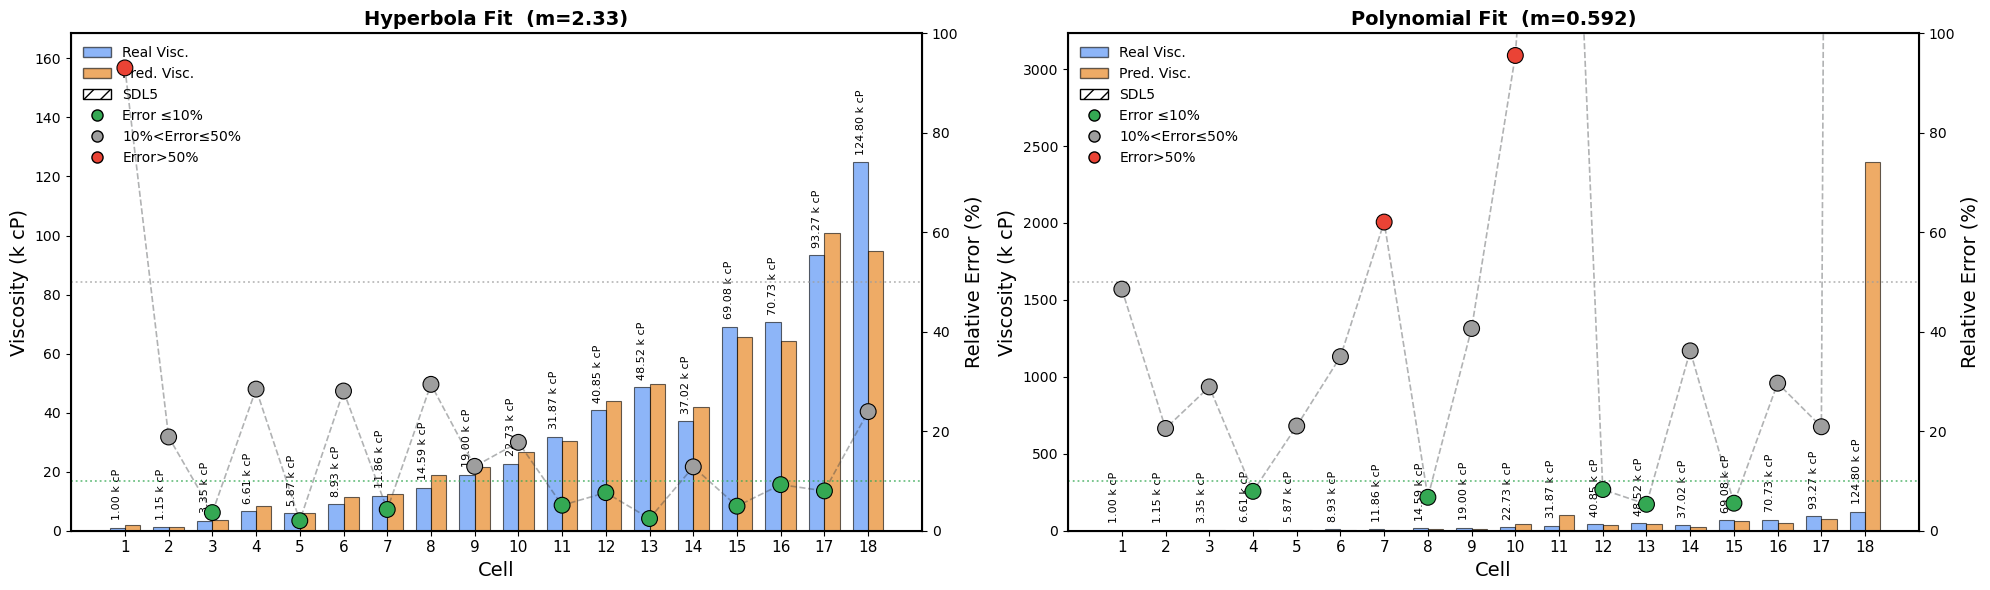

Learned scaling factors: {'poly': 0.592, 'hyperbola': 2.33}


In [3]:
pipeline_out = run_viscosity_pipeline(
    csv_path=csv_path,
    real_viscosity_map=real_viscosity_map,
    visualize=True,
)

print('Learned scaling factors:', pipeline_out['scales'])

In [4]:
pred_cols = [
    'cell',
    'a_poly2',
    'a_hyperbola',
    'real_viscosity',
    'predicted_visc_pol',
    'predicted_visc_hyp',
    'rel_error_pol',
    'rel_error_hyp',
    'is_calibration',
]

pred_df = pipeline_out['predictions'][pred_cols].sort_values('cell').reset_index(drop=True)
display(pred_df)

# Optional: save the predictions table
# pred_df.to_csv('viscosity_predictions_dynamic_analysis_L60kcP.csv', index=False)

,cell,a_poly2,a_hyperbola,real_viscosity,predicted_visc_pol,predicted_visc_hyp,rel_error_pol,rel_error_hyp,is_calibration
0,1,0.868767,0.828541,1000,0.514310,1.930501,48.568984,93.050114,True
1,2,1.548535,0.588634,1154,0.916733,1.371517,20.560404,18.849003,True
2,3,4.019021,1.488845,3347,2.379260,3.469009,28.913641,3.645331,True
3,4,10.283467,3.645120,6611,6.087812,8.493130,7.913898,28.469671,True
4,5,7.822022,2.567812,5865,4.630637,5.983003,21.046260,2.011984,True
5,6,9.805869,4.908922,8930,5.805074,11.437788,34.993570,28.082736,True
6,7,7.601738,5.307322,11860,4.500229,12.366060,62.055404,4.266952,True
7,8,22.988616,8.104554,14590,13.609261,18.883610,6.721996,29.428447,True
8,9,19.045834,9.209514,19000,11.275133,21.458167,40.657192,12.937721,True
9,10,75.081295,11.488910,22730,44.448126,26.769160,95.548290,17.770172,True


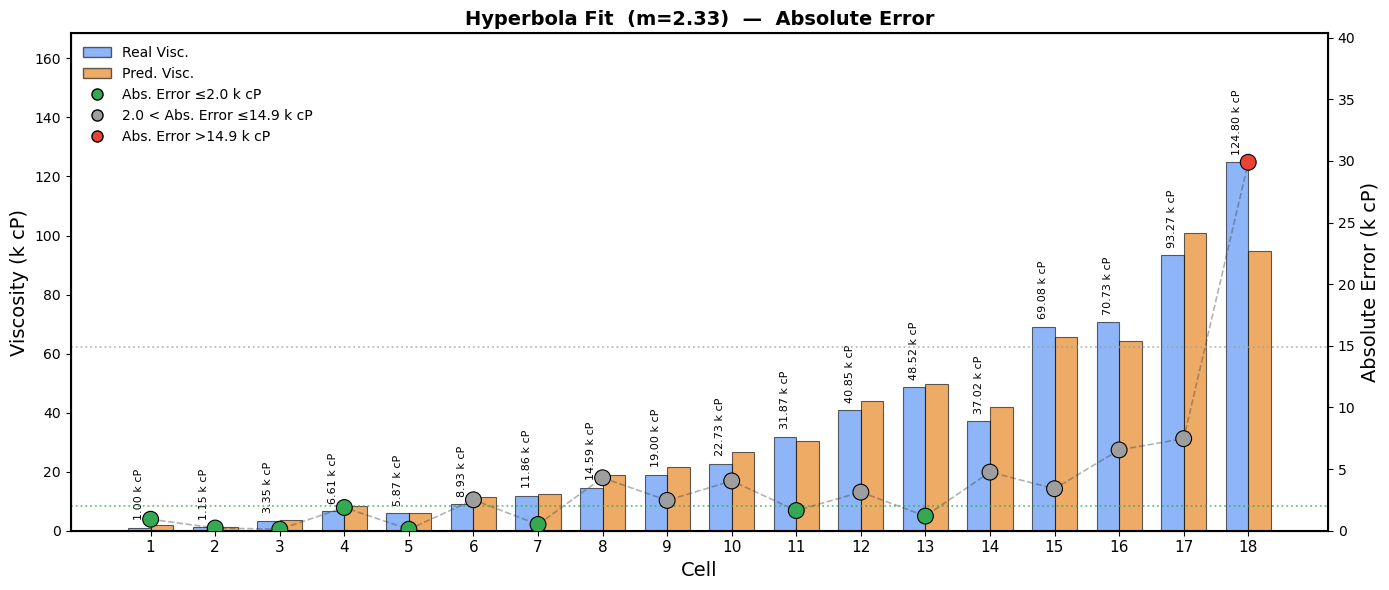

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

df_pred = pipeline_out['predictions'].copy()
all_pred = df_pred.dropna(subset=["predicted_visc_hyp", "real_viscosity_kcp"], how="any").copy()

cells = all_pred["cell"].astype(int).to_numpy()
real = all_pred["real_viscosity_kcp"].to_numpy(float)
pred_hyp = all_pred["predicted_visc_hyp"].to_numpy(float)
abs_err_hyp = np.abs(real - pred_hyp)  # absolute error in k cP

prov = all_pred["provider"].fillna("").astype(str).str.lower().to_numpy() if "provider" in all_pred.columns else np.array([""] * len(all_pred))

x = np.arange(len(cells))
bw = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

has_real = ~np.isnan(real)
for i in range(len(cells)):
    h = "//" if prov[i] == "sdl5" else None
    if has_real[i]:
        ax.bar(x[i] - bw / 2, real[i], bw, color="#4285F4", alpha=0.6, hatch=h, edgecolor="k", lw=0.8)
    ax.bar(x[i] + bw / 2, pred_hyp[i], bw, color="#E37400", alpha=0.6, hatch=h, edgecolor="k", lw=0.8)

y_max = max(
    float(np.nanmax(real[has_real])) if has_real.any() else 0.0,
    float(np.nanmax(pred_hyp)) if pred_hyp.size else 0.0,
    1e-9,
)

for i in range(len(cells)):
    if not has_real[i]:
        continue
    ax.text(x[i] - bw / 2, real[i] + y_max * 0.02, f"{real[i]:.2f} k cP",
            ha="center", va="bottom", fontsize=8, rotation=90)

ax.set_ylabel("Viscosity (k cP)", fontsize=14)
ax.set_xlabel("Cell", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cells, fontsize=11)
ax.set_ylim(0, y_max * 1.35)
ax.grid(False)
m_hyp = pipeline_out['scales']['hyperbola']
ax.set_title(f"Hyperbola Fit  (m={m_hyp})  —  Absolute Error", fontsize=14, fontweight="bold")

ax2 = ax.twinx()
err_max = float(np.nanmax(abs_err_hyp)) if abs_err_hyp.size else 1.0
thr1 = 2.0  # example threshold for good predictions, can be adjusted based on domain knowledge
thr2 = err_max * 0.50
colors = ["#34A853" if e <= thr1 else "#9E9E9E" if e <= thr2 else "#EA4335" for e in abs_err_hyp]
ax2.scatter(x, abs_err_hyp, color=colors, s=130, zorder=5, edgecolor="k", lw=0.8)
ax2.plot(x, abs_err_hyp, color="#3C4043", lw=1.2, linestyle="--", alpha=0.4)
ax2.set_ylabel("Absolute Error (k cP)", fontsize=14)
ax2.axhline(thr1, color="#34A853", linestyle=":", lw=1.3, alpha=0.7)
ax2.axhline(thr2, color="#9E9E9E", linestyle=":", lw=1.3, alpha=0.7)
ax2.set_ylim(0, err_max * 1.35)

leg = [
    Patch(facecolor="#4285F4", alpha=0.6, edgecolor="k", label="Real Visc."),
    Patch(facecolor="#E37400", alpha=0.6, edgecolor="k", label="Pred. Visc."),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#34A853", markeredgecolor="k", markersize=8, label=f"Abs. Error ≤{thr1:.1f} k cP"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#9E9E9E", markeredgecolor="k", markersize=8, label=f"{thr1:.1f} < Abs. Error ≤{thr2:.1f} k cP"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#EA4335", markeredgecolor="k", markersize=8, label=f"Abs. Error >{thr2:.1f} k cP"),
]
ax.legend(handles=leg, fontsize=10, frameon=False)

for sp in ax.spines.values():
    sp.set_linewidth(1.5)

plt.tight_layout()
plt.show()